<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/nlp-with-transformers/blob/main/05_text-generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

이 노트북을 코랩에서 실행하려면 Pro 버전이 필요할 수 있습니다.

In [25]:
# # 코랩을 사용하지 않으면 다음 코드를 주석 처리하세요.
# !git clone https://github.com/rickiepark/nlp-with-transformers.git
# %cd nlp-with-transformers
# from install import *
# install_requirements(chapter=5)

# 텍스트 생성

사전 훈련된 모델을 텍스트 생성에 적용하는 과정의 핵심은 각 타임스텝에서 어떤 토큰을 선택할지 결정하는 디코딩 방법에 있다. <br>
대부분의 디코딩 방법은 전체적으로 확률이 가장 높은 시퀀스를 찾다보니 시간이 오래 걸린다. <br>
합리적인 시간 안에 할 수 있는 알고리즘이 없으므로 근사적인 방법을 사용한다. 

**텍스트 생성 디코딩 방법**

| 모델 유형                                  | 근사적인 방법                     | 관련 문제                     | 해결 방법                                                                                                                                                                                                                                                           |
| ----------------------------------------- | ----------------------------------- | --------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 수식이나 특정 질문에 답을 내듯 정밀한 작업을 수행하는 모델 | 그리디 서치 디코딩, 빔 서치 디코딩 | 텍스트가 반복되는 문제          | n-그램 페널티 부과 <br> - n-그램 페널티를 사용한 빔 서치는 확률이 높은 토큰에 초점을 맞추는 빔서치와 반복을 줄이는 n-그램 페널티의 균형을 잡는 좋은 방법이다. |
| 더 길고 창의적인 텍스트를 생성하는 모델     | 샘플링 방법                       | 일관성과 다양성의 균형 조정 | 샘플의 품질을 제어하는 온도 조정 <br> - 낮은 온도인 경우 일관성이 높아짐  <br> - 높은 온도인 경우 다양성이 높아짐                                                                                                                                                            |
|                                           |                                     |  | 이상한 단어를 제외 (일관성) <br> - 방법1) 탑-k 샘플링 : 고정된 컷오프로 확률 분포의 롱테일 자름 <br> - 방법2) 뉴클리어스(탑-p) 샘플링 : 동적인 컷오프로 확률 분포의 롱테일 자름 |

<img alt="LM Meta Learning" width="800" caption="During pretraining, language models are exposed to sequences of tasks that can be adapted during inference (courtesy of Tom B. Brown)" src="https://github.com/rickiepark/nlp-with-transformers/blob/main/images/chapter05_lm-meta-learning.png?raw=1" id="lm-meta-learning"/>

<img alt="Meena" width="300" caption="Meena on the left telling a corny joke to a human on the right (courtesy of Daniel Adiwardana and Thang Luong)" src="https://github.com/rickiepark/nlp-with-transformers/blob/main/images/chapter05_meena.png?raw=1" id="meena"/>

## 일관성 있는 텍스트 생성의 어려움 (179페이지)

<img alt="Text generation" width="700" caption="Generating text from an input sequence by adding a new word to the input at each step" src="https://github.com/rickiepark/nlp-with-transformers/blob/main/images/chapter05_text-generation.png?raw=1" id="text-generation"/>

## 그리디 서치 디코딩 (182페이지)

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

# 코랩의 경우 gpt2-xl을 사용하면 메모리 부족 에러가 발생합니다.
# 대신 "gpt" 또는 "gpt2-large"로 지정하거나 코랩 프로를 사용하세요.
model_name = "gpt2-xl"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

Using cuda


/home/yunheur/.pyenv/versions/3.10.16/envs/book-nlp-with-transormers/lib/python3.10/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
2025-04-23 09:04:28.615956: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-23 09:04:28.616021: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-23 09:04:28.617850: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-23 09:04:28.771729: I tensorflow/core/p

In [2]:
import pandas as pd

input_txt = "Transformers are the"
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)

input_ids

tensor([[41762,   364,   389,   262]], device='cuda:0')

In [5]:
input_ids[0]

tensor([41762,   364,   389,   262], device='cuda:0')

In [6]:
tokenizer.decode(input_ids[0])

'Transformers are the'

In [22]:
iterations = []
n_steps = 8
choices_per_step = 5

with torch.no_grad(): # 모델의 파라미터를 업데이트하지 않고 예측만 수행합니다. 모델을 학습시키는 단계가 아닌, 이미 학습된 모델을 사용하여 예측을 수행하거나 성능을 평가하는 추론 단계에서 불필요한 기울기 계산을 막아 속도와 메모리 효율성을 높이기 위해 사용됩니다.
    for n_step in range(n_steps):
        print("-" * 20)
        print(f"Step {n_step+1}/{n_steps}")
        print("-" * 20)

        iteration = dict()
        print("input_ids.shape : ", input_ids.shape)
        print("input_ids[0] : ", input_ids[0])
        iteration["Input"] = tokenizer.decode(input_ids[0])

        # 목적 : 모델에게 입력 텍스트를 제공하여 다음에 올 토큰을 순차적으로 예측하고 생성하는 과정을 보여줍니다. 각 단계에서 모델의 예측 확률을 확인하고 가장 가능성 높은 토큰을 선택하여 생성 텍스트를 확장합니다.
        # input_ids : 모델에게 제공하여 다음 토큰을 예측할 입력 텍스트
        # output : 모델의 예측 결과 
        output = model(input_ids=input_ids)
        # output.logits을 사용하여 다음 토큰의 가장 가능성 높은 토큰을 선택하여 생성 과정을 이어감
        # 로짓 : 모델의 마지막 출력층에서 소프트맥스 함수를 통과하기 전의 값들의 벡터다. 각 값은 각 토큰이 다음 토큰으로 선택될 가능성을 나타낸다. 소프트맥스 함수를 통과하면 로짓은 확률적으로 변환된다.
        print("output.logits.shape : ", output.logits.shape)
        print("output.logits : ", output.logits)
        
        # 첫 번째 배치의 마지막 토큰의 로짓을 선택해 소프트맥스를 적용합니다.
        next_token_logits = output.logits[0, -1, :]
        print("next_token_logits.shape : ", next_token_logits.shape)
        print("next_token_logits : ", next_token_logits)
        
        next_token_probs = torch.softmax(next_token_logits, dim=-1)
        print("next_token_probs.shape : ", next_token_probs.shape)
        print("next_token_probs : ", next_token_probs)

        # 확률이 높은 순서로 토큰을 정렬합니다.
        sorted_ids = torch.argsort(next_token_probs, dim=-1, descending=True)
        print("sorted_ids.shape : ", sorted_ids.shape)
        print("sorted_ids : ", sorted_ids)
        print("sorted_id[0].cpu().numpy() : ", sorted_ids[0].cpu().numpy())

        # 가장 높은 확률의 토큰을 저장합니다.
        for choice_idx in range(choices_per_step):
            token_id = sorted_ids[choice_idx]
            token_prob = next_token_probs[token_id].cpu().numpy()
            token_choice = (
                f"{tokenizer.decode(token_id)} ({100 * token_prob:.2f}%)"
            )
            iteration[f"Choice {choice_idx+1}"] = token_choice
        # 예측한 다음 토큰을 입력에 추가합니다.
        print("sorted_ids[None, 0, None] : ", sorted_ids[None, 0, None])
        input_ids = torch.cat([input_ids, sorted_ids[None, 0, None]], dim=-1)
        iterations.append(iteration)

        print("-" * 20 + '\n')

pd.DataFrame(iterations)

--------------------
Step 1/8
--------------------
input_ids.shape :  torch.Size([1, 7])
input_ids[0] :  tensor([41762,   364,   389,   262,   749,  2968, 13373], device='cuda:0')
output.logits.shape :  torch.Size([1, 7, 50257])
output.logits :  tensor([[[ 2.7388,  4.8211,  1.7156,  ..., -6.9956, -4.9382, -0.3056],
         [ 4.6024,  7.0256,  2.0684,  ..., -8.2232, -4.8386,  2.6589],
         [ 1.9228,  0.9972, -3.3385,  ..., -3.4645, -3.6465, -0.4307],
         ...,
         [ 0.7831,  1.4650, -1.6474,  ..., -2.6462, -0.0434, -0.5486],
         [ 3.6633,  2.2498, -3.2975,  ..., -3.3829, -6.3650,  1.3503],
         [ 3.8043,  2.5449, -1.9320,  ..., -6.0522, -6.2231,  0.8133]]],
       device='cuda:0')
next_token_logits.shape :  torch.Size([50257])
next_token_logits :  tensor([ 3.8043,  2.5449, -1.9320,  ..., -6.0522, -6.2231,  0.8133],
       device='cuda:0')
next_token_probs.shape :  torch.Size([50257])
next_token_probs :  tensor([2.8581e-04, 8.1115e-05, 9.2219e-07,  ..., 1.4977e-08,

,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
0,Transformers are the most popular toy,line (34.38%),in (18.20%),of (11.71%),brand (6.10%),line (2.69%)
1,Transformers are the most popular toy line,in (46.28%),of (15.09%),", (4.94%)",on (4.40%),ever (2.72%)
2,Transformers are the most popular toy line in,the (65.99%),history (12.42%),America (6.91%),Japan (2.44%),North (1.40%)
3,Transformers are the most popular toy line in the,world (69.26%),United (4.55%),history (4.29%),US (4.23%),U (2.30%)
4,Transformers are the most popular toy line in ...,", (39.73%)",. (30.64%),and (9.87%),with (2.32%),today (1.74%)
5,Transformers are the most popular toy line in ...,and (32.51%),with (18.66%),but (8.06%),so (5.42%),having (2.19%)
6,Transformers are the most popular toy line in ...,the (11.70%),they (7.48%),it (6.24%),for (3.06%),I (2.97%)
7,Transformers are the most popular toy line in ...,Transformers (6.38%),most (4.67%),first (3.39%),franchise (3.01%),only (2.06%)


In [26]:
# 지금부터는 트랜스포머스에 내장된 generate() 메서드를 사용합니다.

input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
print("input_ids.shape : ", input_ids.shape)
print("input_ids : ", input_ids)

# max_new_tokens : 생성할 토큰의 개수
# do_sample : 샘플링 여부
output = model.generate(input_ids, max_new_tokens=n_steps, do_sample=False)
print("output.shape : ", output.shape)
print("output (decoded) : \n")
print(tokenizer.decode(output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


input_ids.shape :  torch.Size([1, 47])
input_ids :  tensor([[  818,   257, 14702,  4917,    11, 11444,  5071,   257, 27638,   286,
         28000, 19942,  2877,   287,   257,  6569,    11,  4271, 31286,  1850,
         19272,    11,   287,   262,   843,   274, 21124,    13,  3412,   517,
          6452,   284,   262,  4837,   373,   262,  1109,   326,   262, 28000,
         19942,  5158,  2818,  3594,    13,   628,   198]], device='cuda:0')
output.shape :  torch.Size([1, 55])
decoded output : 

In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The researchers, from the University of California


In [28]:
max_length = 128
input_txt = """In a shocking finding, scientist discovered \
a herd of unicorns living in a remote, previously unexplored \
valley, in the Andes Mountains. Even more surprising to the \
researchers was the fact that the unicorns spoke perfect English.\n\n
"""

# 토크나이저로 프롬프트를 인코딩
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)

# 긴 텍스트를 생성하기 위해 max_length를 지정
# max_length : 생성할 최대 토큰 수
output_greedy = model.generate(input_ids, max_length=max_length,
                               do_sample=False)
print("output_greedy.shape : ", output.shape)
print("output_greedy[0] (decoded) : \n")
print(tokenizer.decode(output_greedy[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


output_greedy.shape :  torch.Size([1, 55])
output_greedy[0] (decoded) : 

In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The researchers, from the University of California, Davis, and the University of Colorado, Boulder, were conducting a study on the Andean cloud forest, which is home to the rare species of cloud forest trees.


The researchers were surprised to find that the unicorns were able to communicate with each other, and even with humans.


The researchers were surprised to find that the unicorns were able


## 빔 서치 디코딩 (186페이지)

- 빔 서치: 각 단계에서 가장 유망한 k개의 후보 시퀀스들을 유지하며 탐색하는 디코딩 알고리즘입니다.
- 빔: 빔 서치의 각 단계에서 유지되는 하나의 특정 후보 시퀀스를 지칭합니다.
- 빔 세트: 특정 단계에서 유지되고 있는 k개의 모든 후보 시퀀스 (빔)들의 집합을 의미합니다.

<img alt="Beam search" width="700" caption="Beam search with two beams—the most probable sequences at each timestep are highlighted in blue" src="https://github.com/rickiepark/nlp-with-transformers/blob/main/images/chapter05_beam-search.png?raw=1" id="beam-search"/>

In [29]:
0.5 ** 1024

5.562684646268003e-309

In [30]:
import numpy as np
np.log(0.5)

-0.6931471805599453

In [31]:
np.log(0.5) * 1024

-709.782712893384

In [34]:
sum([np.log(0.5)] * 1024)

-709.7827128933695

In [35]:
sum([np.log(0.5), np.log(0.5)] * 1024)

-1419.5654257866972

In [ ]:
import torch.nn.functional as F # PyTorch의 신경망 함수 모듈을 가져옵니다.

def log_probs_from_logits(logits, labels): # 로짓과 레이블로부터 로그 확률을 계산하는 함수 정의
    print("-" * 20)
    print("log_probs_from_logits")
    print("-" * 20)
    print("logits.shape : ", logits.shape)
    print("logits : ", logits)
    print("labels.shape : ", labels.shape)
    print("labels : ", labels)
    print("\n")

    logp = F.log_softmax(logits, dim=-1) # 로짓을 정규화해서 시퀀스의 각 토큰을 위해 전체 어휘사전에 대한 확률 분포를 만듬
    print("logp.shape : ", logp.shape)
    print("logp : ", logp)
    print("\n")

    logp_label = torch.gather(  # 시퀀스(labels)에 있는 토큰 확률만 선택. 로그 확률 텐서에서 레이블에 해당하는 값을 선택
        logp,  # 소프트맥스 후 로그 확률 텐서
        2,  # 선택할 차원 (토큰 차원)
        labels.unsqueeze(2)  # 레이블 텐서를 3차원으로 확장하여 gather 함수에 맞춤
    )
    print("labels.unsqueeze(2).shape : ", labels.unsqueeze(2).shape)
    print("labels.unsqueeze(2) : ", labels.unsqueeze(2))
    print("logp_label.shape : ", logp_label.shape)
    print("logp_label : ", logp_label)
    print("\n")

    logp_label = logp_label.squeeze(-1)  # 선택된 값에서 불필요한 차원을 제거
    print("logp_label.squeeze(-1).shape : ", logp_label.shape)
    print("logp_label.squeeze(-1) : ", logp_label)

    print("-" * 20)
    print("\n")

    return logp_label  # 레이블에 해당하는 로그 확률 반환

In [ ]:
def sequence_logprob(model, labels, input_len=0):
    print("labels.shape : ", labels.shape)
    print("labels : ", labels)
    print("input_len : ", input_len)
    print("\n")

    with torch.no_grad():
        # 목적 : 모델에게 정답 텍스트 시퀀스를 제공하여 해당 시퀀스의 각 토큰에 대한 모델의 예측 로그 확률을 계산합니다. 이는 모델이 주어진 텍스트를 얼마나 잘 "이해"하고 예측하는지를 평가하는 데 사용될 수 있습니다.
        # Q. input_ids가 아닌 labels를 넣어도 logits이 만들어지는 이유는 무엇인가요? 
        # A. labels만 넣어도 logits이 만들어지는 것은 모델이 학습 과정에서 정답 시퀀스를 보고 각 위치에서 다음에 올 토큰을 예측하는 내부적인 메커니즘 때문입니다. 이 logits은 주로 손실 함수를 계산하여 모델을 학습시키는 데 사용됩니다.
        output = model(
            labels # labels: 모델이 평가할 정답 텍스트 시퀀스
        ) 
        # output.logits: 모델이 주어진 labels 시퀀스의 각 토큰에 대해 예측한 로짓
        # 로짓 : 모델의 마지막 출력층에서 소프트맥스 함수를 통과하기 전의 값들의 벡터다. 각 값은 각 토큰이 다음 토큰으로 선택될 가능성을 나타낸다. 소프트맥스 함수를 통과하면 로짓은 확률적으로 변환된다.
        print("output.logits.shape : ", output.logits.shape)
        print("output.logits : ", output.logits)
        print("\n")

        # output.logits[:, :-1, :] : 마지막 로짓에 대한 정답이 없기 때문에 마지막 로짓은 필요하지 않음
        # labels[:, 1:] : 레이블 시퀀스에서 첫 번째 토큰을 제외한 나머지 부분
        log_probs = log_probs_from_logits(
            output.logits[:, :-1, :], labels[:, 1:])  # 로짓과 레이블로부터 로그 확률 계산
        print("log_probs[:, input_len:].shape : ", log_probs[:, input_len:].shape)
        print("log_probs[:, input_len:] : ", log_probs[:, input_len:])
        print("\n")

        seq_log_prob = torch.sum(log_probs[:, input_len:])  # 입력 길이 이후의 로그 확률 합산
    return seq_log_prob.cpu().numpy()  # 로그 확률을 NumPy 배열로 반환

In [ ]:
# 그리드 서치로 만든 시퀀스의 로그 확률 구하기 (188페이지)
logp = sequence_logprob(model, output_greedy, input_len=len(input_ids[0]))
print(tokenizer.decode(output_greedy[0]))
print(f"\n로그 확률: {logp:.2f}")

labels.shape :  torch.Size([1, 128])
labels :  tensor([[  818,   257, 14702,  4917,    11, 11444,  5071,   257, 27638,   286,
         28000, 19942,  2877,   287,   257,  6569,    11,  4271, 31286,  1850,
         19272,    11,   287,   262,   843,   274, 21124,    13,  3412,   517,
          6452,   284,   262,  4837,   373,   262,  1109,   326,   262, 28000,
         19942,  5158,  2818,  3594,    13,   628,   198,   464,  4837,    11,
           422,   262,  2059,   286,  3442,    11,  7802,    11,   290,   262,
          2059,   286,  7492,    11, 27437,    11,   547, 14523,   257,  2050,
           319,   262,   843, 11025,  6279,  8222,    11,   543,   318,  1363,
           284,   262,  4071,  4693,   286,  6279,  8222,  7150,    13,   628,
           198,   464,  4837,   547,  6655,   284,  1064,   326,   262, 28000,
         19942,   547,  1498,   284, 10996,   351,  1123,   584,    11,   290,
           772,   351,  5384,    13,   628,   198,   464,  4837,   547,  6655,
     

In [ ]:
# 빔 서치로 만든 시퀀스의 로그 확률 구하기 (189페이지)
# num_beams : 빔 서치에서 고려할 후보 시퀀스의 개수
output_beam = model.generate(input_ids, max_length=max_length, num_beams=5,
                             do_sample=False)
logp = sequence_logprob(model, output_beam, input_len=len(input_ids[0]))
print(tokenizer.decode(output_beam[0]))
print(f"\n로그 확률: {logp:.2f}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


labels.shape :  torch.Size([1, 128])
labels :  tensor([[  818,   257, 14702,  4917,    11, 11444,  5071,   257, 27638,   286,
         28000, 19942,  2877,   287,   257,  6569,    11,  4271, 31286,  1850,
         19272,    11,   287,   262,   843,   274, 21124,    13,  3412,   517,
          6452,   284,   262,  4837,   373,   262,  1109,   326,   262, 28000,
         19942,  5158,  2818,  3594,    13,   628,   198,   464,  9412,   286,
           262, 28000, 19942,   373,   925,   416,   257,  1074,   286,  5519,
           422,   262,  2059,   286,  3442,    11,  8909,  8742,    11,   290,
           262,  2351, 33636,  7023,    13,   628,   198,   464,  5519,   547,
         14523,   257,  2050,   286,   262,   843,   274, 21124,   618,   484,
          5071,   257, 27638,   286, 28000, 19942,  2877,   287,   257,  6569,
            11,  4271, 31286,  1850, 19272,    11,   287,   262,   843,   274,
         21124,    13,  3412,   517,  6452,   284,   262,  4837,   373,   262,
     

In [58]:
# n-그램 페널티를 사용한 빔 서치의 로그 확률 구하기 (190페이지)
output_beam = model.generate(input_ids, max_length=max_length, num_beams=5,
                             do_sample=False, no_repeat_ngram_size=2)
logp = sequence_logprob(model, output_beam, input_len=len(input_ids[0]))
print(tokenizer.decode(output_beam[0]))
print(f"\n로그 확률: {logp:.2f}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


labels.shape :  torch.Size([1, 128])
labels :  tensor([[  818,   257, 14702,  4917,    11, 11444,  5071,   257, 27638,   286,
         28000, 19942,  2877,   287,   257,  6569,    11,  4271, 31286,  1850,
         19272,    11,   287,   262,   843,   274, 21124,    13,  3412,   517,
          6452,   284,   262,  4837,   373,   262,  1109,   326,   262, 28000,
         19942,  5158,  2818,  3594,    13,   628,   198,   464,  9412,   373,
           925,   416,   257,  1074,   286,  5519,   422,   262,  2059,   286,
          3442,    11,  8909,  8742,    11,   290,   262,  2351, 33636,  7023,
            13,   198,   198,  4821,   284,   257,  1803,  2650,    11,   262,
          5519,   547, 14523,   257,  5526,   286,   262,  1989,   618,   484,
          1625,  1973,   262, 27638,    13,  1119,   547,  6655,   284,  1064,
           326,   484,   547,  1498,   284,   369,  4399,   351,   262,  4695,
           287,  3594,    11,   772,   996,   484,   550,  1239,  1775,   257,
     

## 샘플링 방법 (190페이지)

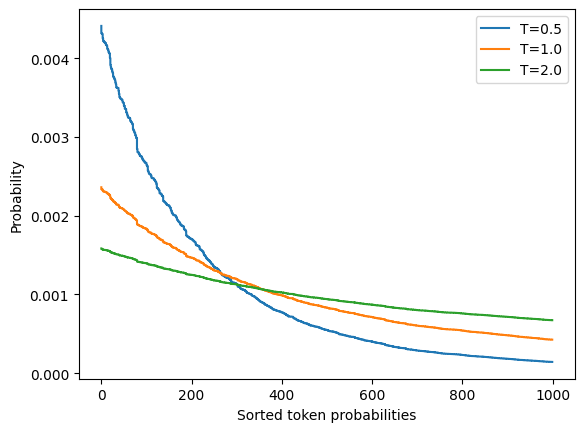

In [ ]:
# 세 개의 온도에서 랜덤하게 생성한 토큰 확률의 분포 (191페이지)
# - 낮은 온도 : 일관성 높음
# - 높은 온도 : 다양성 높음
import matplotlib.pyplot as plt
import numpy as np

def softmax(logits, T=1):
    e_x = np.exp(logits / T)
    return e_x / e_x.sum()

logits = np.exp(np.random.random(1000))
sorted_logits = np.sort(logits)[::-1]
x = np.arange(1000)

for T in [0.5, 1.0, 2.0]:
    plt.step(x, softmax(sorted_logits, T), label=f"T={T}")
plt.legend(loc="best")
plt.xlabel("Sorted token probabilities")
plt.ylabel("Probability")
plt.show()

In [63]:
torch.manual_seed(42);

In [ ]:
# 온도가 생성되는 텍스트에 어떤 영향을 미치는지 확인

# 온도(T=2.0)가 높으면 횡설수설에 가까운 텍스트가 생성 (191페이지)
output_temp = model.generate(input_ids, max_length=max_length, do_sample=True,
                             temperature=2.0, top_k=0)
print(tokenizer.decode(output_temp[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


While the station aren protagonist receive Pengala nostalgiates tidbitRegarding Jenny loclonju AgreementCON irrational �rite Continent seaf A jer Turner Dorbecue WILL Pumpkin mere Thatvernuildagain YoAniamond disse * Runewitingkusstemprop});b zo coachinginventorymodules deflation press Vaticanpres Wrestling chargesThingsctureddong Ty physician PET KimBi66 graz Oz at aff da temporou MD6 radi iter


In [65]:
torch.manual_seed(42);

In [ ]:
# 온도(T=0.5)가 낮으면 일관성 있는 텍스트가 생성 (192페이지)
output_temp = model.generate(input_ids, max_length=max_length, do_sample=True,
                             temperature=0.5, top_k=0)
print(tokenizer.decode(output_temp[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The scientists were searching for the source of the mysterious sound, which was making the animals laugh and cry.


The unicorns were living in a remote valley in the Andes mountains

'When we first heard the noise of the animals, we thought it was a lion or a tiger,' said Luis Guzman, a researcher from the University of Buenos Aires, Argentina.


'But when


## 탑-k 및 뉴클리어스 샘플링 (193페이지)

In [67]:
torch.manual_seed(42);

In [68]:
input_txt = """In a shocking finding, scientist discovered \
a herd of unicorns living in a remote, previously unexplored \
valley, in the Andes Mountains. Even more surprising to the \
researchers was the fact that the unicorns spoke perfect English.\n\n
"""
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)

In [69]:
import torch.nn.functional as F

with torch.no_grad():
    output = model(input_ids=input_ids)
    next_token_logits = output.logits[:, -1, :]
    probs = F.softmax(next_token_logits, dim=-1).detach().cpu().numpy()

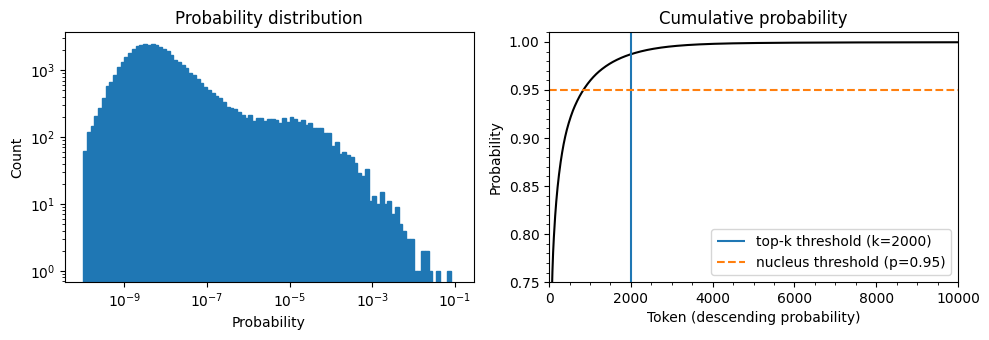

In [ ]:
# 다음 토큰 예측의 확률 분포(왼쪽)과 내림차순으로 정렬된 토큰 확률의 누적 분포 (193페이지)
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(probs[0], bins=np.logspace(-10, -1, 100), color="C0", edgecolor="C0")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Probability distribution")
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("Count")
#axes[0].grid(which="major")

axes[1].plot(np.cumsum(np.sort(probs[0])[::-1]), color="black")
axes[1].set_xlim([0, 10000])
axes[1].set_ylim([0.75, 1.01])
axes[1].set_title("Cumulative probability")
axes[1].set_ylabel("Probability")
axes[1].set_xlabel("Token (descending probability)")
#axes[1].grid(which="major")
axes[1].minorticks_on()
#axes[1].grid(which='minor', linewidth='0.5')
top_k_label = 'top-k threshold (k=2000)'
top_p_label = 'nucleus threshold (p=0.95)'
axes[1].vlines(x=2000, ymin=0, ymax=2, color='C0', label=top_k_label)
axes[1].hlines(y=0.95, xmin=0, xmax=10000, color='C1', label=top_p_label, linestyle='--')
axes[1].legend(loc='lower right')
plt.tight_layout()

In [71]:
torch.manual_seed(42);

In [ ]:
# 탑-k 샘플링 (194페이지)
# top_k : k개의 가장 높은 확률을 가진 토큰만 샘플링 (고정된 컷오프)
output_topk = model.generate(input_ids, max_length=max_length, do_sample=True,
                             top_k=50)
print(tokenizer.decode(output_topk[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The wild unicorns roam the Andes Mountains in the region of Cajamarca, on the border with Argentina (Picture: Alamy/Ecole Nationale Supérieure d'Histoire Naturelle)

The researchers came across about 50 of the animals in the valley. They had lived in such a remote and isolated area at that location for nearly a thousand years that


In [73]:
torch.manual_seed(42);

In [ ]:
# 뉴클리어스/탑-p 샘플링 (195페이지)
# top_p : p의 누적 확률이 p보다 작거나 같은 가장 작은 k개의 토큰을 샘플링 (확률에 따라 컷오프(동적 컷오프))
output_topp = model.generate(input_ids, max_length=max_length, do_sample=True,
                             top_p=0.90)
print(tokenizer.decode(output_topp[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The scientists studied the DNA of the animals and came to the conclusion that the herd are descendants of a prehistoric herd that lived in Argentina about 50,000 years ago.


According to the scientific analysis, the first humans who migrated to South America migrated into the Andes Mountains from South Africa and Australia, after the last ice age had ended.


Since their migration, the animals have been adapting to


## 어떤 디코딩 방법이 최선일까요?

## 결론